# Loan Prediction

Import necessary packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

Import Data

In [5]:
df=pd.read_csv("LoansTrainingSet.csv", low_memory=False)

### Exploratory Data Analysis and Feature Engineering

In [7]:
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Years in current job,Home Ownership,Annual Income,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,000025bb-5694-4cff-b17d-192b1a98ba44,5ebc8bb1-5eb9-4404-b11b-a6eebc401a19,Fully Paid,11520,Short Term,741.0,10+ years,Home Mortgage,33694.0,Debt Consolidation,$584.03,12.3,41.0,10,0,6760,16056,0.0,0.0
1,00002c49-3a29-4bd4-8f67-c8f8fbc1048c,927b388d-2e01-423f-a8dc-f7e42d668f46,Fully Paid,3441,Short Term,734.0,4 years,Home Mortgage,42269.0,other,"$1,106.04",26.3,NaN,17,0,6262,19149,0.0,0.0
2,00002d89-27f3-409b-aa76-90834f359a65,defce609-c631-447d-aad6-1270615e89c4,Fully Paid,21029,Short Term,747.0,10+ years,Home Mortgage,90126.0,Debt Consolidation,"$1,321.85",28.8,NaN,5,0,20967,28335,0.0,0.0
3,00005222-b4d8-45a4-ad8c-186057e24233,070bcecb-aae7-4485-a26a-e0403e7bb6c5,Fully Paid,18743,Short Term,747.0,10+ years,Own Home,38072.0,Debt Consolidation,$751.92,26.2,NaN,9,0,22529,43915,0.0,0.0
4,0000757f-a121-41ed-b17b-162e76647c1f,dde79588-12f0-4811-bab0-e2b07f633fcd,Fully Paid,11731,Short Term,746.0,4 years,Rent,50025.0,Debt Consolidation,$355.18,11.5,NaN,12,0,17391,37081,0.0,0.0


In [8]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,256984.00,13713306.26,34381306.57,505.00,8299.00,14298.00,24367.00,99999999.00
Credit Score,195308.00,1251.12,1762.02,585.00,714.00,733.00,744.00,7510.00
Annual Income,195308.00,71952.72,58877.57,0.00,44321.00,61242.00,86462.00,8713547.00
Years of Credit History,256984.00,18.29,7.08,3.40,13.50,17.00,21.70,70.50
Months since last delinquent,116601.00,34.88,21.85,0.00,16.00,32.00,51.00,176.00
Number of Open Accounts,256984.00,11.11,4.98,0.00,8.00,10.00,14.00,76.00
Number of Credit Problems,256984.00,0.16,0.46,0.00,0.00,0.00,0.00,11.00
Current Credit Balance,256984.00,15406.56,19665.06,0.00,5974.00,11078.00,19319.00,1731412.00
Bankruptcies,256455.00,0.11,0.34,0.00,0.00,0.00,0.00,7.00
Tax Liens,256961.00,0.03,0.25,0.00,0.00,0.00,0.00,11.00


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256984 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       256984 non-null  object 
 1   Customer ID                   256984 non-null  object 
 2   Loan Status                   256984 non-null  object 
 3   Current Loan Amount           256984 non-null  int64  
 4   Term                          256984 non-null  object 
 5   Credit Score                  195308 non-null  float64
 6   Years in current job          245508 non-null  object 
 7   Home Ownership                256984 non-null  object 
 8   Annual Income                 195308 non-null  float64
 9   Purpose                       256984 non-null  object 
 10  Monthly Debt                  256984 non-null  object 
 11  Years of Credit History       256984 non-null  float64
 12  Months since last delinquent  116601 non-nul

In [11]:
df.shape

(256984, 19)

In [12]:
df.isnull().sum()

Loan ID                              0
Customer ID                          0
Loan Status                          0
Current Loan Amount                  0
Term                                 0
Credit Score                     61676
Years in current job             11476
Home Ownership                       0
Annual Income                    61676
Purpose                              0
Monthly Debt                         0
Years of Credit History              0
Months since last delinquent    140383
Number of Open Accounts              0
Number of Credit Problems            0
Current Credit Balance               0
Maximum Open Credit                  0
Bankruptcies                       529
Tax Liens                           23
dtype: int64

In [13]:
missing_percentage = df.isnull().mean() * 100

In [14]:
missing_percentage

Loan ID                         0.00
Customer ID                     0.00
Loan Status                     0.00
Current Loan Amount             0.00
Term                            0.00
Credit Score                   24.00
Years in current job            4.47
Home Ownership                  0.00
Annual Income                  24.00
Purpose                         0.00
Monthly Debt                    0.00
Years of Credit History         0.00
Months since last delinquent   54.63
Number of Open Accounts         0.00
Number of Credit Problems       0.00
Current Credit Balance          0.00
Maximum Open Credit             0.00
Bankruptcies                    0.21
Tax Liens                       0.01
dtype: float64

In [15]:
df['Months since last delinquent'].fillna(df['Months since last delinquent'].median(), inplace=True)
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

Loan ID                         0
Customer ID                     0
Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Years in current job            0
Home Ownership                  0
Annual Income                   0
Purpose                         0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
dtype: int64

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,186099.00,18154629.10,38532074.23,975.00,9006.00,15051.00,27881.50,99999999.00
Credit Score,186099.00,1243.68,1750.28,585.00,714.00,733.00,744.00,7510.00
Annual Income,186099.00,73121.58,59658.93,4033.00,45095.00,62465.00,87882.00,8713547.00
Years of Credit History,186099.00,18.07,6.83,3.40,13.50,16.90,21.50,70.50
Months since last delinquent,186099.00,33.31,14.74,0.00,32.00,32.00,32.00,176.00
Number of Open Accounts,186099.00,11.16,4.99,0.00,8.00,10.00,14.00,76.00
Number of Credit Problems,186099.00,0.15,0.46,0.00,0.00,0.00,0.00,10.00
Current Credit Balance,186099.00,15506.56,18981.77,0.00,6050.00,11187.00,19481.00,1730472.00
Bankruptcies,186099.00,0.11,0.33,0.00,0.00,0.00,0.00,7.00
Tax Liens,186099.00,0.03,0.24,0.00,0.00,0.00,0.00,10.00


In [18]:
df["Credit Score"]=df["Credit Score"].fillna(df["Credit Score"].median())

In [19]:
df["Annual Income"] = df["Annual Income"].fillna(df["Annual Income"].median())

In [20]:
df["Years in current job"] = df["Years in current job"].str.replace(' years', '').str.replace(' year', '').str.replace("+", "").str.replace("<", "").astype(float)

In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,186099.00,18154629.10,38532074.23,975.00,9006.00,15051.00,27881.50,99999999.00
Credit Score,186099.00,1243.68,1750.28,585.00,714.00,733.00,744.00,7510.00
Years in current job,186099.00,5.96,3.50,1.00,3.00,6.00,10.00,10.00
Annual Income,186099.00,73121.58,59658.93,4033.00,45095.00,62465.00,87882.00,8713547.00
Years of Credit History,186099.00,18.07,6.83,3.40,13.50,16.90,21.50,70.50
Months since last delinquent,186099.00,33.31,14.74,0.00,32.00,32.00,32.00,176.00
Number of Open Accounts,186099.00,11.16,4.99,0.00,8.00,10.00,14.00,76.00
Number of Credit Problems,186099.00,0.15,0.46,0.00,0.00,0.00,0.00,10.00
Current Credit Balance,186099.00,15506.56,18981.77,0.00,6050.00,11187.00,19481.00,1730472.00
Bankruptcies,186099.00,0.11,0.33,0.00,0.00,0.00,0.00,7.00


In [22]:
df["Years in current job"] = df["Years in current job"].fillna(df["Years in current job"].mean())

In [23]:
#Bazı eksik değerlerin çok az olduğu ve önemsiz olduğunu düşündüğüm için siliyorum.
df.dropna(subset=["Bankruptcies","Tax Liens"], inplace=True)

In [24]:
df.isnull().sum()

Loan ID                         0
Customer ID                     0
Loan Status                     0
Current Loan Amount             0
Term                            0
Credit Score                    0
Years in current job            0
Home Ownership                  0
Annual Income                   0
Purpose                         0
Monthly Debt                    0
Years of Credit History         0
Months since last delinquent    0
Number of Open Accounts         0
Number of Credit Problems       0
Current Credit Balance          0
Maximum Open Credit             0
Bankruptcies                    0
Tax Liens                       0
dtype: int64

In [25]:
df.shape

(186099, 19)

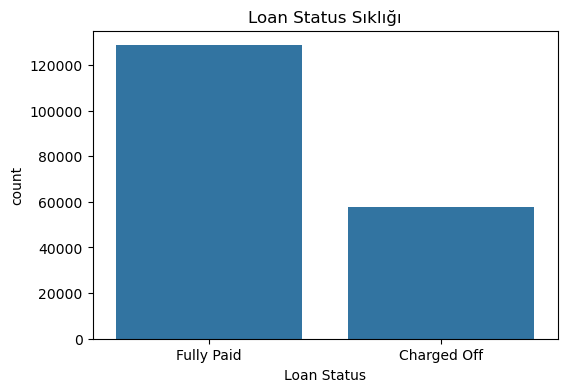

In [26]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan Status')
plt.title("Loan Status Sıklığı")
plt.show()

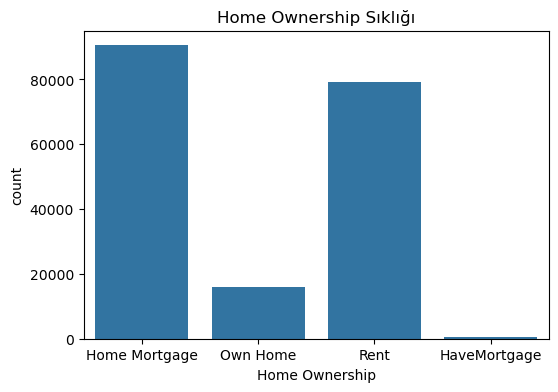

In [27]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Home Ownership')
plt.title("Home Ownership Sıklığı")
plt.show()

In [28]:
df["Home Ownership"]=df["Home Ownership"].str.replace("Own Home","Home Mortgage")

In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,186099.00,18154629.10,38532074.23,975.00,9006.00,15051.00,27881.50,99999999.00
Credit Score,186099.00,1243.68,1750.28,585.00,714.00,733.00,744.00,7510.00
Years in current job,186099.00,5.96,3.50,1.00,3.00,6.00,10.00,10.00
Annual Income,186099.00,73121.58,59658.93,4033.00,45095.00,62465.00,87882.00,8713547.00
Years of Credit History,186099.00,18.07,6.83,3.40,13.50,16.90,21.50,70.50
Months since last delinquent,186099.00,33.31,14.74,0.00,32.00,32.00,32.00,176.00
Number of Open Accounts,186099.00,11.16,4.99,0.00,8.00,10.00,14.00,76.00
Number of Credit Problems,186099.00,0.15,0.46,0.00,0.00,0.00,0.00,10.00
Current Credit Balance,186099.00,15506.56,18981.77,0.00,6050.00,11187.00,19481.00,1730472.00
Bankruptcies,186099.00,0.11,0.33,0.00,0.00,0.00,0.00,7.00


In [30]:
outliers=df.quantile(q=.97, numeric_only=True)

In [31]:
df=df[(df["Current Loan Amount"]<outliers["Current Loan Amount"])]

In [32]:
df=df[(df["Credit Score"]<outliers["Credit Score"])]

In [33]:
df=df[(df["Annual Income"]<outliers["Annual Income"])]

In [34]:
df["Term"] = df["Term"].astype("category")
df["Loan Status"] = df["Loan Status"].astype("category")
df["Home Ownership"] = df["Home Ownership"].astype("category")
df["Purpose"] = df["Purpose"].astype("category")

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,142421.00,13943.80,8126.38,975.00,7872.00,12085.00,19219.00,39304.00
Credit Score,142421.00,1132.21,1547.11,585.00,712.00,732.00,743.00,7270.00
Years in current job,142421.00,5.95,3.50,1.00,3.00,6.00,10.00,10.00
Annual Income,142421.00,67328.18,30632.07,4033.00,44546.00,60924.00,84235.00,172061.00
Years of Credit History,142421.00,17.88,6.76,3.70,13.30,16.70,21.30,70.50
Months since last delinquent,142421.00,33.36,14.78,0.00,32.00,32.00,32.00,176.00
Number of Open Accounts,142421.00,11.13,4.96,0.00,8.00,10.00,14.00,76.00
Number of Credit Problems,142421.00,0.15,0.45,0.00,0.00,0.00,0.00,10.00
Current Credit Balance,142421.00,14717.97,15062.08,0.00,5997.00,11046.00,18983.00,818209.00
Bankruptcies,142421.00,0.11,0.33,0.00,0.00,0.00,0.00,5.00


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142421 entries, 0 to 256983
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Loan ID                       142421 non-null  object  
 1   Customer ID                   142421 non-null  object  
 2   Loan Status                   142421 non-null  category
 3   Current Loan Amount           142421 non-null  int64   
 4   Term                          142421 non-null  category
 5   Credit Score                  142421 non-null  float64 
 6   Years in current job          142421 non-null  float64 
 7   Home Ownership                142421 non-null  category
 8   Annual Income                 142421 non-null  float64 
 9   Purpose                       142421 non-null  category
 10  Monthly Debt                  142421 non-null  object  
 11  Years of Credit History       142421 non-null  float64 
 12  Months since last delinquent  14242

In [37]:
df["Maximum Open Credit"]=pd.to_numeric(df["Maximum Open Credit"], errors="coerce")

In [38]:
df["Maximum Open Credit"] = df["Maximum Open Credit"].replace(0, pd.NA)


In [39]:
df['Current Credit Balance'] = pd.to_numeric(df['Current Credit Balance'], errors='coerce')

In [40]:
def cleaner_func(value):
    if isinstance(value, str):
        return float(value.replace('$','').replace(',','').strip())
    return value    

In [41]:
df['Current Loan Amount'] = df['Current Loan Amount'].apply(cleaner_func)
df['Monthly Debt'] = df['Monthly Debt'].apply(cleaner_func)
df['Current Credit Balance'] = df['Current Credit Balance'].apply(cleaner_func)

In [42]:
df['Credit Utilization'] = df['Current Credit Balance'] / df['Maximum Open Credit']

In [43]:
df["Credit Utilization"] = df["Credit Utilization"].fillna(0)

In [44]:
df.isnull().sum()

Loan ID                           0
Customer ID                       0
Loan Status                       0
Current Loan Amount               0
Term                              0
Credit Score                      0
Years in current job              0
Home Ownership                    0
Annual Income                     0
Purpose                           0
Monthly Debt                      0
Years of Credit History           0
Months since last delinquent      0
Number of Open Accounts           0
Number of Credit Problems         0
Current Credit Balance            0
Maximum Open Credit             941
Bankruptcies                      0
Tax Liens                         0
Credit Utilization                0
dtype: int64

In [45]:
df.drop(columns=["Current Credit Balance","Maximum Open Credit"], inplace=True)

In [46]:
df["Loan Status"]=df["Loan Status"].map({"Fully Paid": 1, "Charged Off": 0})

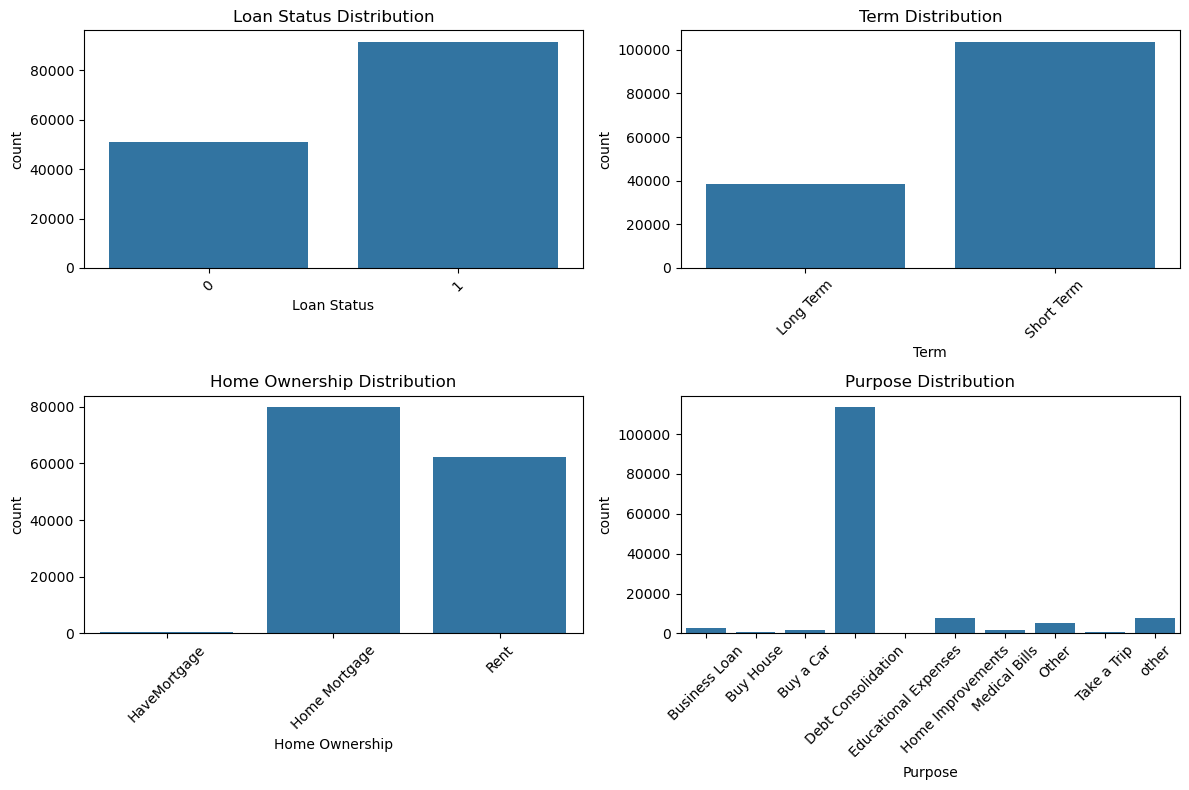

In [47]:
cat_cols = ["Loan Status", "Term", "Home Ownership", "Purpose"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)  
plt.tight_layout()
plt.show()


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142421 entries, 0 to 256983
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Loan ID                       142421 non-null  object  
 1   Customer ID                   142421 non-null  object  
 2   Loan Status                   142421 non-null  category
 3   Current Loan Amount           142421 non-null  int64   
 4   Term                          142421 non-null  category
 5   Credit Score                  142421 non-null  float64 
 6   Years in current job          142421 non-null  float64 
 7   Home Ownership                142421 non-null  category
 8   Annual Income                 142421 non-null  float64 
 9   Purpose                       142421 non-null  category
 10  Monthly Debt                  142421 non-null  float64 
 11  Years of Credit History       142421 non-null  float64 
 12  Months since last delinquent  14242

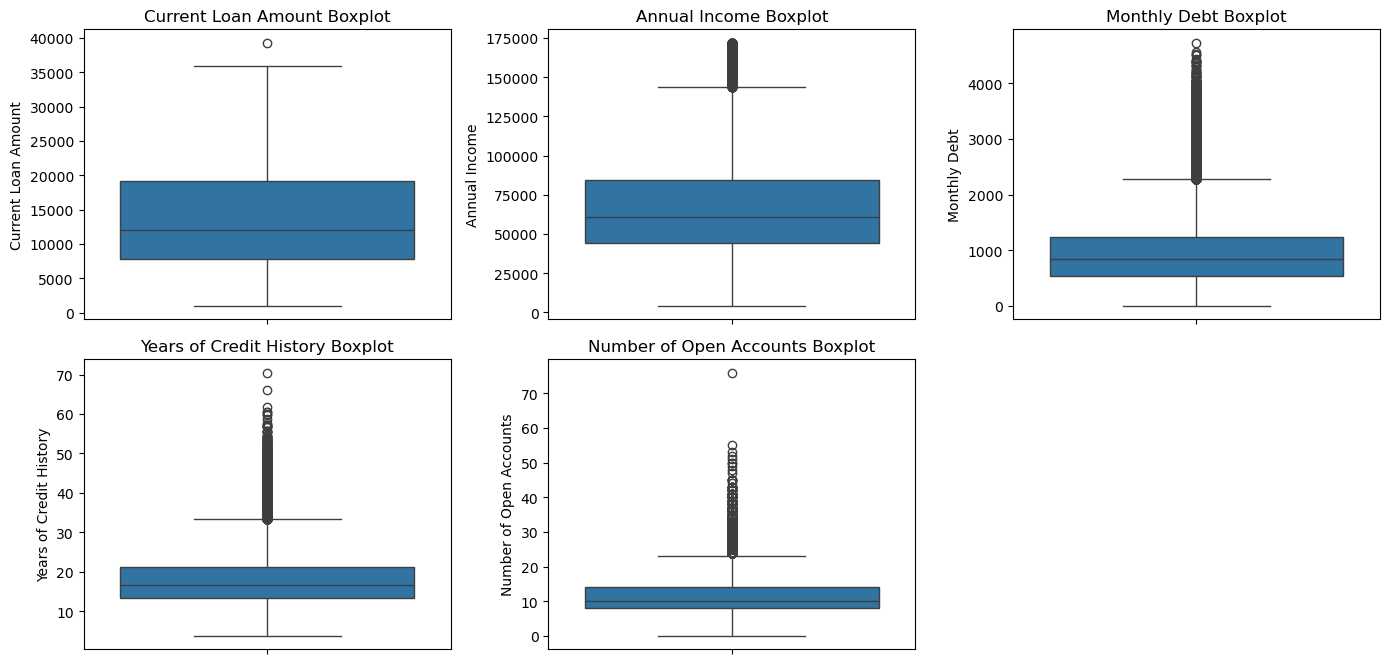

In [49]:
num_cols = [
    "Current Loan Amount", 
    "Annual Income", 
    "Monthly Debt", 
    "Years of Credit History", 
    "Number of Open Accounts"
]

plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()


In [50]:
outliers = df.quantile(q=0.96, numeric_only=True)
print(outliers)

Current Loan Amount             31802.00
Credit Score                     6940.00
Years in current job               10.00
Annual Income                  133712.00
Monthly Debt                     2110.02
Years of Credit History            32.00
Months since last delinquent       70.00
Number of Open Accounts            21.00
Number of Credit Problems           1.00
Bankruptcies                        1.00
Tax Liens                           0.00
Credit Utilization                  0.94
Name: 0.96, dtype: float64


In [51]:
df=df[(df['Number of Open Accounts']<outliers['Number of Open Accounts'])]

In [52]:
df=df[(df['Current Loan Amount']<outliers['Current Loan Amount'])]

In [53]:
df=df[(df['Years of Credit History']<outliers['Years of Credit History'])]

In [54]:
df=df[(df['Annual Income']<outliers['Annual Income'])]

In [55]:
df["Monthly Debt"] = pd.to_numeric(df["Monthly Debt"], errors="coerce")

In [56]:
df.columns.tolist()

['Loan ID',
 'Customer ID',
 'Loan Status',
 'Current Loan Amount',
 'Term',
 'Credit Score',
 'Years in current job',
 'Home Ownership',
 'Annual Income',
 'Purpose',
 'Monthly Debt',
 'Years of Credit History',
 'Months since last delinquent',
 'Number of Open Accounts',
 'Number of Credit Problems',
 'Bankruptcies',
 'Tax Liens',
 'Credit Utilization']

In [57]:
df=df[(df["Monthly Debt"]<outliers["Monthly Debt"])]

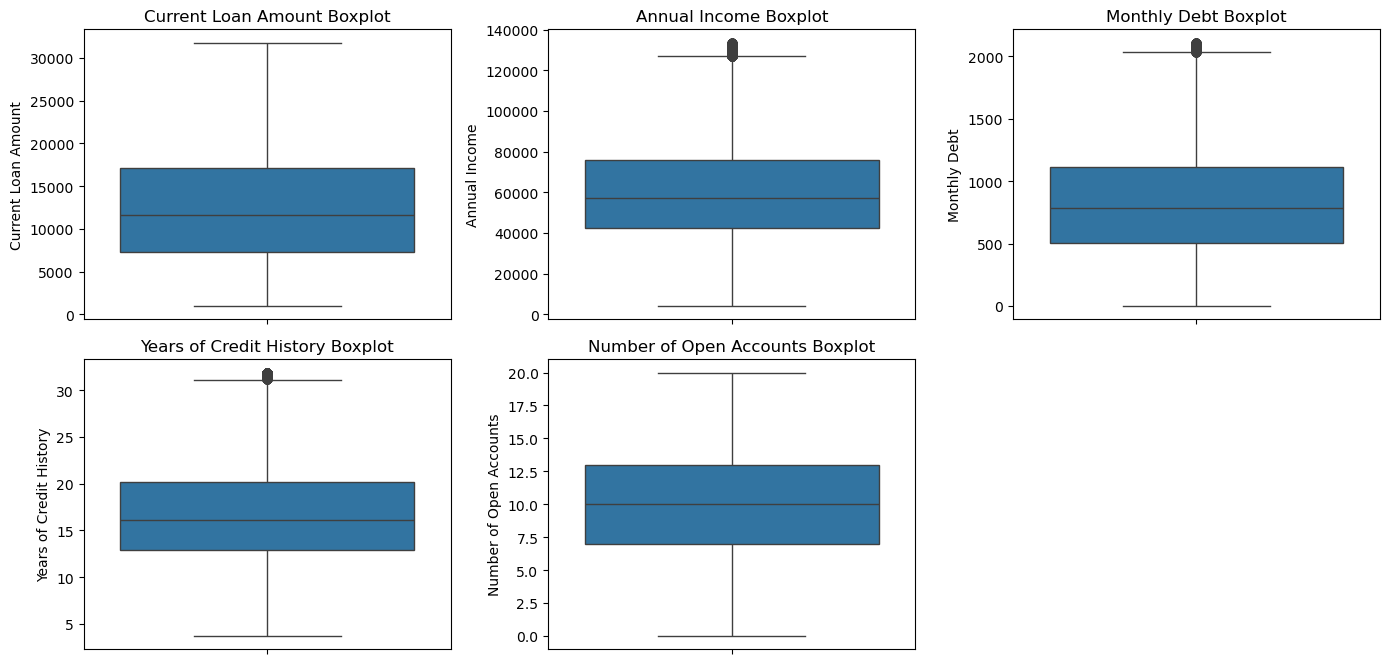

In [58]:
num_cols = [
    "Current Loan Amount", 
    "Annual Income", 
    "Monthly Debt", 
    "Years of Credit History", 
    "Number of Open Accounts"
]

plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=col)
    plt.title(f"{col} Boxplot")
plt.tight_layout()
plt.show()


In [59]:
outliers = df.quantile(q=0.95, numeric_only=True)
print(outliers)

Current Loan Amount             25413.00
Credit Score                     6770.00
Years in current job               10.00
Annual Income                  109098.00
Monthly Debt                     1663.73
Years of Credit History            27.40
Months since last delinquent       67.00
Number of Open Accounts            18.00
Number of Credit Problems           1.00
Bankruptcies                        1.00
Tax Liens                           0.00
Credit Utilization                  0.93
Name: 0.95, dtype: float64


In [60]:
df=df[(df["Monthly Debt"]<outliers["Monthly Debt"])]

In [61]:
df=df[(df['Years of Credit History']<outliers['Years of Credit History'])]

In [62]:
df=df[(df['Annual Income']<outliers['Annual Income'])]

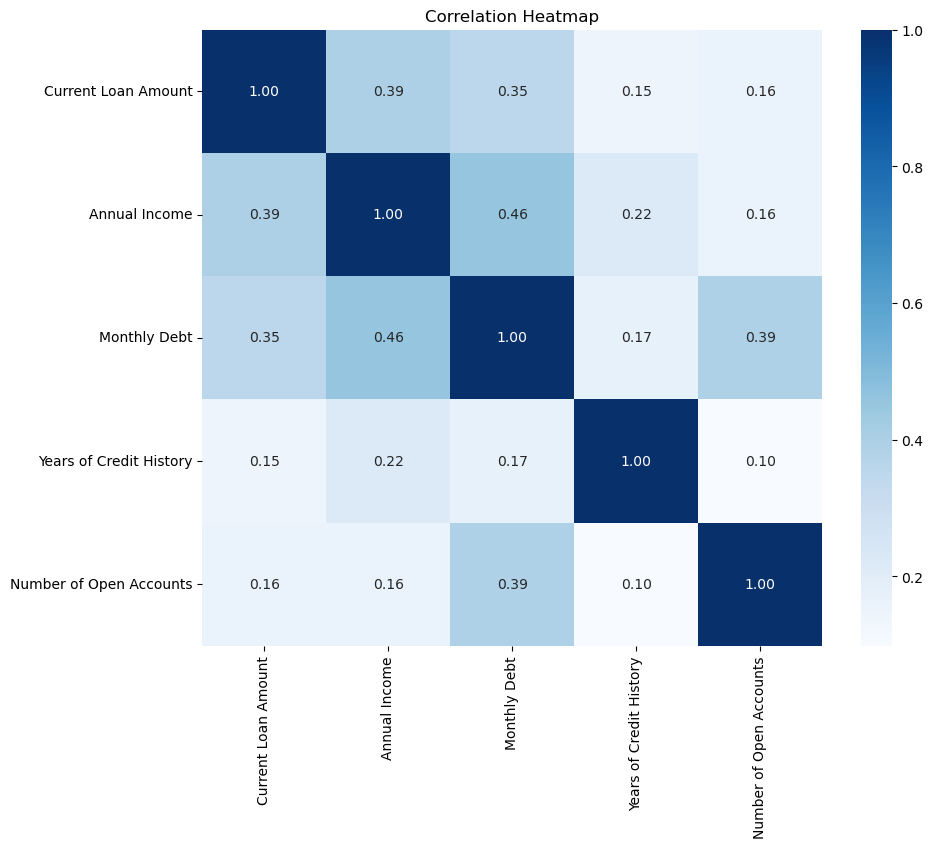

In [63]:
corr = df[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [64]:
df.columns

Index(['Loan ID', 'Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Years in current job', 'Home Ownership',
       'Annual Income', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Bankruptcies', 'Tax Liens',
       'Credit Utilization'],
      dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102907 entries, 0 to 256982
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   Loan ID                       102907 non-null  object  
 1   Customer ID                   102907 non-null  object  
 2   Loan Status                   102907 non-null  category
 3   Current Loan Amount           102907 non-null  int64   
 4   Term                          102907 non-null  category
 5   Credit Score                  102907 non-null  float64 
 6   Years in current job          102907 non-null  float64 
 7   Home Ownership                102907 non-null  category
 8   Annual Income                 102907 non-null  float64 
 9   Purpose                       102907 non-null  category
 10  Monthly Debt                  102907 non-null  float64 
 11  Years of Credit History       102907 non-null  float64 
 12  Months since last delinquent  10290

In [66]:
x = df.drop(['Loan ID', 'Customer ID', 'Loan Status'], axis=1)
y=df[["Loan Status"]]

In [67]:
x=pd.get_dummies(x, drop_first=True)

### Modelling

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, random_state=42)

## GaussianNB - BernoulliNB

In [71]:
g=GaussianNB()
b=BernoulliNB()

In [72]:
g.fit(x_train,y_train)

GaussianNB()

In [73]:
gtahmin=g.predict(x_test)

In [74]:
accuracy_score(gtahmin,y_test)

0.7091633466135459

In [75]:
confusion_matrix(gtahmin,y_test)

array([[ 1671,   208],
       [ 5778, 12925]], dtype=int64)

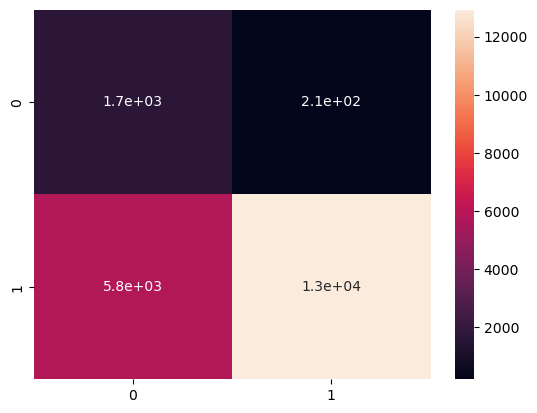

In [76]:
sns.heatmap(confusion_matrix(gtahmin,y_test), annot=True);

In [77]:
print(classification_report(gtahmin,y_test))

              precision    recall  f1-score   support

           0       0.22      0.89      0.36      1879
           1       0.98      0.69      0.81     18703

    accuracy                           0.71     20582
   macro avg       0.60      0.79      0.59     20582
weighted avg       0.91      0.71      0.77     20582



In [78]:
b.fit(x_train,y_train)

BernoulliNB()

In [79]:
btahmin=g.predict(x_test)

In [80]:
accuracy_score(btahmin,y_test)

0.7091633466135459

In [81]:
confusion_matrix(btahmin,y_test)

array([[ 1671,   208],
       [ 5778, 12925]], dtype=int64)

In [82]:
print(classification_report(btahmin,y_test))

              precision    recall  f1-score   support

           0       0.22      0.89      0.36      1879
           1       0.98      0.69      0.81     18703

    accuracy                           0.71     20582
   macro avg       0.60      0.79      0.59     20582
weighted avg       0.91      0.71      0.77     20582



## Logistic Regression

In [84]:
l=LogisticRegression()

In [85]:
l.fit(x_train,y_train)

LogisticRegression()

In [86]:
ltahmin=l.predict(x_test)

In [87]:
print(classification_report(ltahmin,y_test))

              precision    recall  f1-score   support

           0       0.23      0.81      0.36      2139
           1       0.97      0.69      0.81     18443

    accuracy                           0.70     20582
   macro avg       0.60      0.75      0.58     20582
weighted avg       0.89      0.70      0.76     20582



## Decision Tree

In [89]:
d=DecisionTreeClassifier()

In [90]:
d.fit(x_train,y_train)

DecisionTreeClassifier()

In [91]:
dtahmin=d.predict(x_test)

In [92]:
print(classification_report(dtahmin,y_test))

              precision    recall  f1-score   support

           0       0.70      0.61      0.65      8533
           1       0.75      0.81      0.78     12049

    accuracy                           0.73     20582
   macro avg       0.72      0.71      0.72     20582
weighted avg       0.73      0.73      0.73     20582



In [93]:
confusion_matrix(dtahmin,y_test)

array([[5214, 3319],
       [2235, 9814]], dtype=int64)

## Random Forest

In [95]:
r=RandomForestClassifier()

In [96]:
r.fit(x_train,y_train)

RandomForestClassifier()

In [97]:
rtahmin=r.predict(x_test)

In [98]:
accuracy_score(rtahmin,y_test)

0.8317947721309883

In [99]:
print(classification_report(rtahmin,y_test))

              precision    recall  f1-score   support

           0       0.64      0.86      0.73      5587
           1       0.94      0.82      0.88     14995

    accuracy                           0.83     20582
   macro avg       0.79      0.84      0.81     20582
weighted avg       0.86      0.83      0.84     20582



In [100]:
confusion_matrix(rtahmin,y_test)

array([[ 4787,   800],
       [ 2662, 12333]], dtype=int64)

## GradientBoosting

In [102]:
h=GradientBoostingClassifier()

In [103]:
h.fit(x_train,y_train)

GradientBoostingClassifier()

In [104]:
htahmin=h.predict(x_test)

In [105]:
print(classification_report(htahmin,y_test))

              precision    recall  f1-score   support

           0       0.38      0.74      0.50      3849
           1       0.92      0.73      0.81     16733

    accuracy                           0.73     20582
   macro avg       0.65      0.73      0.66     20582
weighted avg       0.82      0.73      0.75     20582



In [106]:
confusion_matrix(htahmin,y_test)

array([[ 2849,  1000],
       [ 4600, 12133]], dtype=int64)

## KNeighbors

In [214]:
k=KNeighborsClassifier(n_neighbors=5, n_jobs=1)

In [216]:
k.fit(x_train,y_train)

KNeighborsClassifier(n_jobs=1)

In [218]:
ktahmin=k.predict(np.array(x_test))

In [220]:
print(classification_report(ktahmin,y_test))

              precision    recall  f1-score   support

           0       0.45      0.56      0.50      5895
           1       0.80      0.72      0.76     14687

    accuracy                           0.68     20582
   macro avg       0.63      0.64      0.63     20582
weighted avg       0.70      0.68      0.68     20582

